In [101]:
import numpy as np 
import pandas as pd 
import os
from glob import glob
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from skimage import io
import random
from skimage import exposure
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [102]:
all_xray_df = pd.read_csv('../input/data/Data_Entry_2017.csv')
all_image_paths = {os.path.basename(x): x for x in 
                   glob(os.path.join('..', 'input/data', 'images*', '*', '*.png'))}
print('Scans found:', len(all_image_paths), ', Total Headers', all_xray_df.shape[0])
all_xray_df['path'] = all_xray_df['Image Index'].map(all_image_paths.get)
#all_xray_df['Patient Age'] = all_xray_df['Patient Age'].map(lambda x: int(x[:-1]))
all_xray_df.head()

Scans found: 112120 , Total Headers 112120


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,path
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN,../input/data/images_001/images/00000001_000.png
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN,../input/data/images_001/images/00000001_001.png
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN,../input/data/images_001/images/00000001_002.png
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN,../input/data/images_001/images/00000002_000.png
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN,../input/data/images_001/images/00000003_000.png


In [103]:
# Ambil semua label unik dari kolom 'Finding Labels'
all_labels = sorted(set(label for labels in all_xray_df['Finding Labels'].str.split('|') for label in labels))

# Simpan hanya baris dengan satu label aktif (tidak multi-label)
single_label_df = all_xray_df[all_xray_df['Finding Labels'].str.count('\|') == 0].copy()

# Tambahkan kolom 'label' sebagai target (sama dengan isi kolom 'Finding Labels')
single_label_df['label'] = single_label_df['Finding Labels']

# Kolom akhir yang ingin ditampilkan
single_label_df = single_label_df[["Image Index", "label", "path"]]
single_label_df.head()

,Image Index,label,path
0,00000001_000.png,Cardiomegaly,../input/data/images_001/images/00000001_000.png
3,00000002_000.png,No Finding,../input/data/images_001/images/00000002_000.png
4,00000003_000.png,Hernia,../input/data/images_001/images/00000003_000.png
5,00000003_001.png,Hernia,../input/data/images_001/images/00000003_001.png
6,00000003_002.png,Hernia,../input/data/images_001/images/00000003_002.png


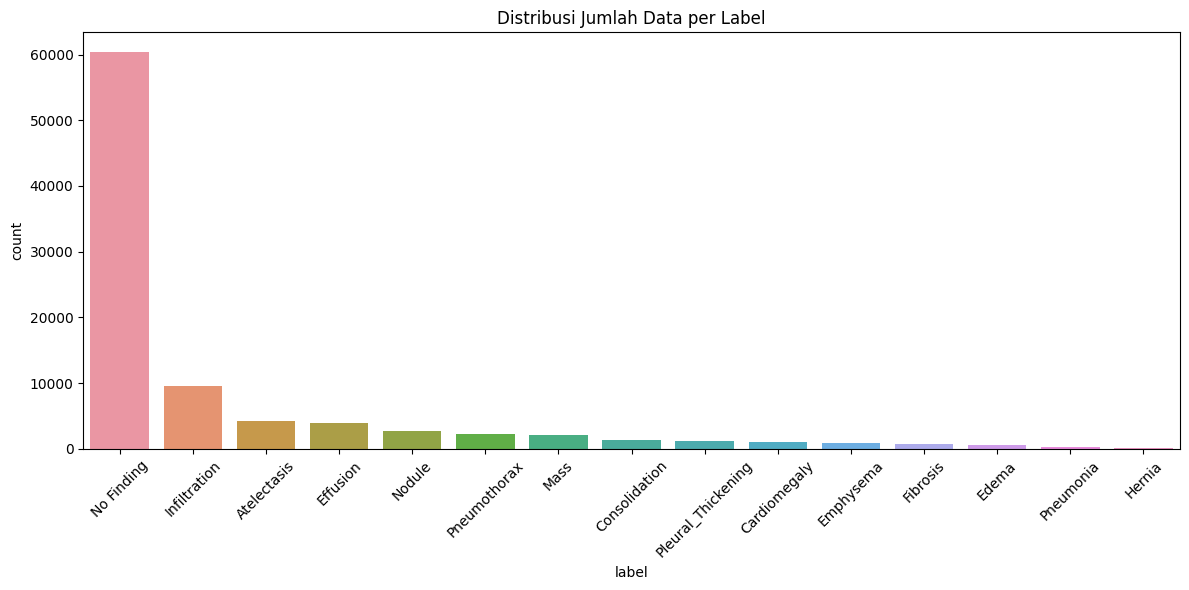

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.countplot(data=single_label_df, x='label', order=single_label_df['label'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Distribusi Jumlah Data per Label")
plt.tight_layout()
plt.show()


/tmp/ipykernel_31/3317577050.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  single_label_df = filtered_df.groupby('label').apply(lambda x: x.sample(n=min(5000, len(x)), random_state=42)).reset_index(drop=True)


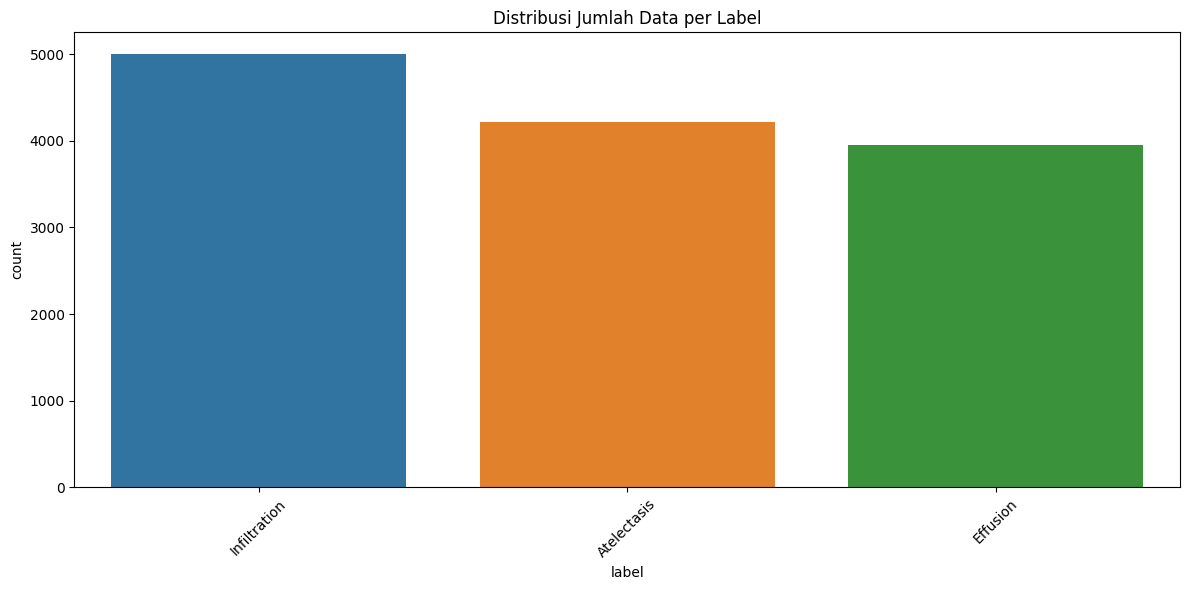

In [105]:
target_labels = ["Infiltration", "Atelectasis", "Effusion"]

# Filter hanya untuk label yang diinginkan
filtered_df = single_label_df[single_label_df['label'].isin(target_labels)].copy()

# Ambil maksimal 5000 data untuk masing-masing label
single_label_df = filtered_df.groupby('label').apply(lambda x: x.sample(n=min(5000, len(x)), random_state=42)).reset_index(drop=True)

plt.figure(figsize=(12, 6))
sns.countplot(data=single_label_df, x='label', order=single_label_df['label'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Distribusi Jumlah Data per Label")
plt.tight_layout()
plt.show()

In [106]:
import cv2
import numpy as np

def clahe_enhancement(img):
    # Pastikan input dalam uint8
    img = img.astype(np.uint8)
    
    # Cek jumlah channel gambar
    if len(img.shape) == 3:  # RGB gambar dengan 3 channel
        # Ubah ke grayscale jika gambar RGB
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:  # Jika gambar sudah grayscale (1 channel)
        gray = img

    # Terapkan CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    
    # Kembalikan ke 3 channel RGB (untuk gambar grayscale yang ditingkatkan)
    img_clahe = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)
    
    # Konversi ke float dan normalisasi
    return img_clahe.astype('float32') / 255.0


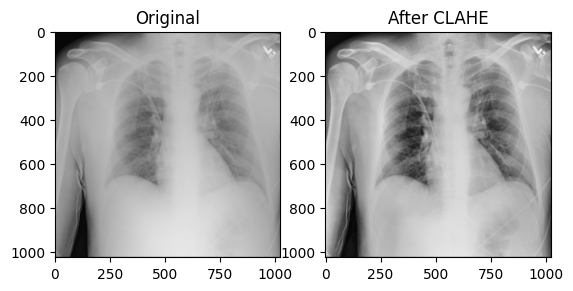

In [107]:
sample_path = single_label_df['path'].iloc[0]
img = cv2.imread(sample_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_clahe = clahe_enhancement(img_rgb)

plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(img_rgb, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("After CLAHE")
plt.imshow(img_clahe, cmap='gray')
plt.show()


In [108]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    preprocessing_function=clahe_enhancement,
)

valid_test_datagen = ImageDataGenerator(
    preprocessing_function=clahe_enhancement,
)


In [109]:
# Membagi dataset menjadi data train + validasi dan test
train_valid_df, test_df = train_test_split(single_label_df, test_size=0.2, random_state=42, stratify=single_label_df['label'])

# Membagi data train + validasi menjadi data train dan data validasi
train_df, valid_df = train_test_split(train_valid_df, test_size=0.1, random_state=42, stratify=train_valid_df['label'])

In [110]:
IMG_SIZE = (224, 224)  # Bisa juga 320x320
BATCH_SIZE = 32

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

valid_generator = valid_test_datagen.flow_from_dataframe(
    dataframe=valid_df,
    x_col='path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = valid_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 9482 validated image filenames belonging to 3 classes.
Found 1054 validated image filenames belonging to 3 classes.
Found 2634 validated image filenames belonging to 3 classes.


In [111]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC

base_model = DenseNet121(weights='/kaggle/input/densenet/keras/densenet121_imagenet/2/model.weights.h5', include_top=False, input_shape=(224, 224, 3))

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
output = Dense(len(target_labels), activation='softmax')(x)  # target_labels = 4 kelas yang kamu pakai

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy', AUC(name='auc')]
             )


In [112]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)
]

history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=20,
    callbacks=callbacks
)


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


297/297 ━━━━━━━━━━━━━━━━━━━━ 555s 1s/step - accuracy: 0.4182 - auc: 0.5947 - loss: 1.1361 - val_accuracy: 0.5493 - val_auc: 0.7468 - val_loss: 0.9318
Epoch 2/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 260s 857ms/step - accuracy: 0.5561 - auc: 0.7428 - loss: 0.9521 - val_accuracy: 0.5911 - val_auc: 0.7727 - val_loss: 0.8894
Epoch 3/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 266s 875ms/step - accuracy: 0.6083 - auc: 0.7855 - loss: 0.8785 - val_accuracy: 0.5133 - val_auc: 0.7164 - val_loss: 1.0428
Epoch 4/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 268s 884ms/step - accuracy: 0.6190 - auc: 0.7985 - loss: 0.8541 - val_accuracy: 0.6120 - val_auc: 0.8079 - val_loss: 0.8257
Epoch 5/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 262s 862ms/step - accuracy: 0.6502 - auc: 0.8288 - loss: 0.7913 - val_accuracy: 0.6376 - val_auc: 0.8209 - val_loss: 0.8026
Epoch 6/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 261s 860ms/step - accuracy: 0.6692 - auc: 0.8379 - loss: 0.7696 - val_accuracy: 0.5968 - val_auc: 0.7968 - val_loss: 0.8531
Epoch 7/20
297/297 ━━━━━━━━━━━

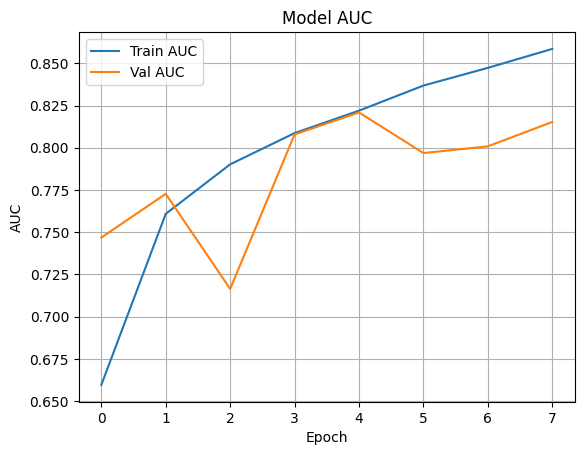

In [113]:
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.title('Model AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)
plt.show()

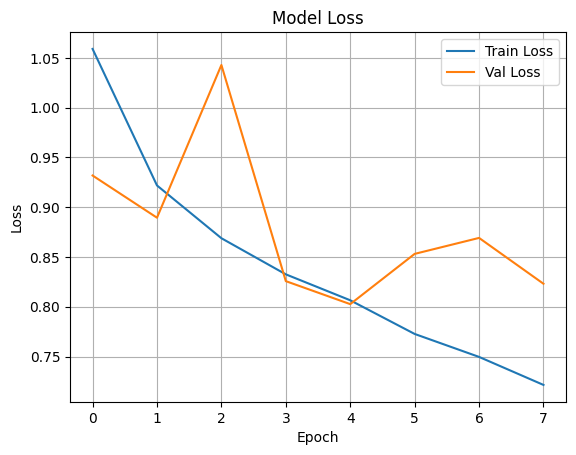

In [114]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [115]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Prediksi probabilitas
y_pred_prob = model.predict(test_generator)
# Konversi ke label prediksi (kelas dengan nilai probabilitas tertinggi)
y_pred = np.argmax(y_pred_prob, axis=1)

# Label asli
y_true = test_generator.classes

# Daftar label
class_labels = list(test_generator.class_indices.keys())

83/83 ━━━━━━━━━━━━━━━━━━━━ 69s 692ms/step


In [116]:
# Skor akurasi
acc = accuracy_score(y_true, y_pred)
# Skor recall macro average
rec = recall_score(y_true, y_pred, average='macro')
# Skor f1 macro average
f1 = f1_score(y_true, y_pred, average='macro')

print(f"Akurasi  : {acc:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

# Laporan lengkap
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))


Akurasi  : 0.6264
Recall   : 0.6226
F1-score : 0.6125

Classification Report:

              precision    recall  f1-score   support

 Atelectasis       0.73      0.39      0.51       843
    Effusion       0.59      0.75      0.66       791
Infiltration       0.62      0.73      0.67      1000

    accuracy                           0.63      2634
   macro avg       0.65      0.62      0.61      2634
weighted avg       0.64      0.63      0.62      2634



1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


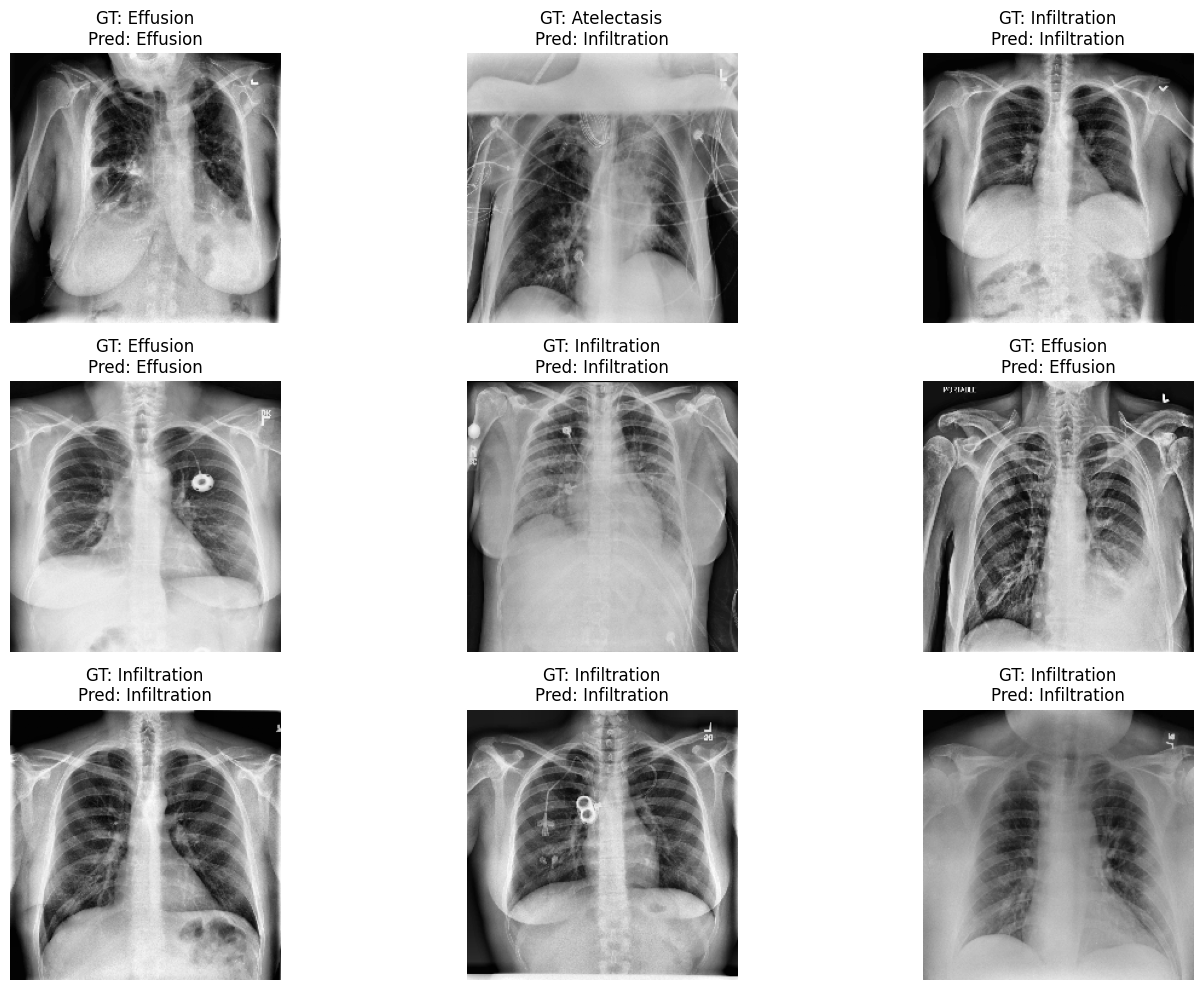

In [117]:
# Ambil batch pertama dari test_generator
images, true_labels = next(test_generator)

# Prediksi batch ini
pred_probs = model.predict(images)
pred_labels = np.argmax(pred_probs, axis=1)
true_labels = np.argmax(true_labels, axis=1)

# Visualisasi 9 gambar pertama
plt.figure(figsize=(15, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    plt.axis('off')
    plt.title(f"GT: {class_labels[true_labels[i]]}\nPred: {class_labels[pred_labels[i]]}")
plt.tight_layout()
plt.show()


In [118]:
model.save('best_mod.keras')